In [168]:
# !pip install aeon

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import torch
from torch import nn
import torch.nn.functional as F
from skorch import NeuralNetClassifier
from skorch.callbacks import EpochScoring
from skorch.dataset import ValidSplit
from sklearn.metrics import accuracy_score
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint

DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

## 2D Convolutional Neural Networks

DermaMNIST is a small benchmark dataset from MedMNIST for skin-lesion image classification. It is based on HAM10000 and contains 10,015 dermatoscopic images of pigmented skin lesions, resized to MNIST-like $28 \times 28$ color images. The task is 7-class multi-class classification, with official train, validation, and test splits of 7,007, 1,003, and 2,005 images.

Labels are:

* akiec: Actinic keratoses and intraepithelial carcinoma
* bcc: Basal cell carcinoma
* bkl: Benign keratosis-like lesions
* df: Dermatofibroma
* nv: Melanocytic nevi
* vasc: Vascular lesions
* mel: Melanoma


In [170]:
files = np.load("Data/dermamnist.npz")

train_images = files["train_images"]
train_labels = files["train_labels"]

validation_images = files["val_images"]
validation_labels = files["val_labels"]

test_images = files["test_images"]
test_labels = files["test_labels"]

train_images.shape, train_labels.shape, validation_images.shape, validation_labels.shape, test_images.shape, test_labels.shape

((7007, 28, 28, 3),
 (7007, 1),
 (1003, 28, 28, 3),
 (1003, 1),
 (2005, 28, 28, 3),
 (2005, 1))

In [171]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6], dtype=uint8)

Text(0.5, 1.0, '[0]')

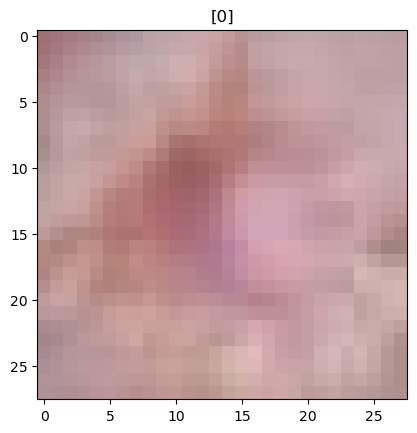

In [172]:
i = 0
plt.imshow(train_images[i])
plt.title(train_labels[i])

In [173]:
train_images = train_images.astype(np.float32).transpose(0, 3, 1, 2) / 255.0
validation_images = validation_images.astype(np.float32).transpose(0, 3, 1, 2) / 255.0
test_images = test_images.astype(np.float32).transpose(0, 3, 1, 2) / 255.0
train_labels = train_labels.ravel()
validation_labels = validation_labels.ravel()
test_labels = test_labels.ravel()

train_images.shape, train_labels.shape, validation_images.shape, validation_labels.shape, test_images.shape, test_labels.shape

((7007, 3, 28, 28),
 (7007,),
 (1003, 3, 28, 28),
 (1003,),
 (2005, 3, 28, 28),
 (2005,))

In [174]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(train_images, train_labels)
dummy_clf.score(test_images, test_labels)

0.6688279301745635

In [175]:
class Conv2DClassifier(nn.Module):
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d(output_size=(1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        x shape: (batch_size, in_channels, height, width)
        """
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [176]:
validation_images.shape, validation_labels.shape

((1003, 3, 28, 28), (1003,))

In [177]:
from skorch.helper import predefined_split
from torch.utils.data import TensorDataset

valid_ds = TensorDataset(torch.Tensor(validation_images), torch.Tensor(validation_labels))

### Vanilla CNN

In [178]:
net = NeuralNetClassifier(
    Conv2DClassifier,
    module__in_channels=train_images.shape[1],
    module__num_classes=np.unique(train_labels).shape[0],

    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    max_epochs=10,
    batch_size=32,
    lr=1e-4,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
        Checkpoint(
            monitor="valid_acc_best", 
            load_best=True,
            f_history=None,
            f_optimizer=None,
        )
    ],
    device=DEVICE,

    train_split=predefined_split(valid_ds)
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.Conv2DClassifier'>,
  module__in_channels=3,
  module__num_classes=7,
)

In [179]:
net.fit(train_images, train_labels)

  epoch    train_acc    train_loss    valid_acc    valid_loss    cp     dur
-------  -----------  ------------  -----------  ------------  ----  ------
      1       0.5807        1.2946       0.6979        0.9958     +  2.6244
      2       0.6956        0.9130       0.7149        0.8589     +  2.4661
      3       0.7089        0.8358       0.7298        0.8131     +  2.4988
      4       0.7153        0.8031       0.7358        0.7858     +  2.7542
      5       0.7211        0.7824       0.7388        0.7711     +  2.7795
      6       0.7250        0.7671       0.7438        0.7595     +  2.5161
      7       0.7280        0.7544       0.7488        0.7529     +  2.4621
      8       0.7293        0.7432       0.7488        0.7434        2.6305
      9       0.7313        0.7331       0.7478        0.7349        2.4915
     10       0.7330        0.7240       0.7507        0.7301     +  2.4509


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Conv2DClassifier(
    (features): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
    )
    (pool): AdaptiveAvgPool2d(output_size=(1, 1))
    (classifier): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=128, out_features=7, bias=True)
    )
  ),
)

In [180]:
y_pred = net.predict(test_images)
accuracy_score(test_labels, y_pred)

0.7276807980049875

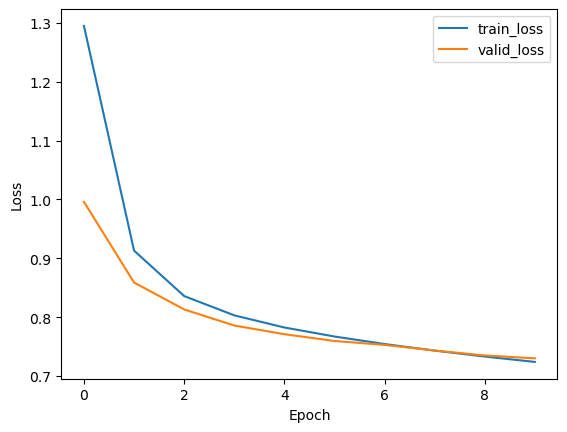

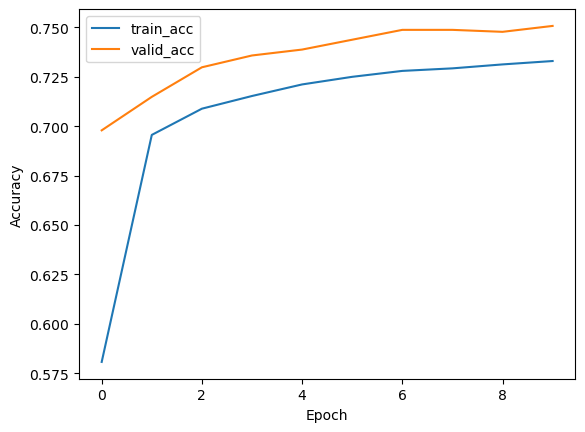

In [181]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

### Resnet

In [182]:
from torchvision.models import resnet18, ResNet18_Weights

class ResNet18Classifier(nn.Module):
    def __init__(self, num_classes, pretrained=True, freeze_features=True):
        super().__init__()

        weights = ResNet18_Weights.DEFAULT if pretrained else None
        self.model = resnet18(weights=weights)

        if freeze_features:
            for name, param in self.model.named_parameters():
                if not name.startswith("fc."):
                    param.requires_grad = False

        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [184]:
net = NeuralNetClassifier(
    ResNet18Classifier,
    module__num_classes=np.unique(train_labels).shape[0],

    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    max_epochs=10,
    batch_size=32,
    lr=1e-4,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
        Checkpoint(
            monitor="valid_acc_best", 
            load_best=True,
            f_history=None,
            f_optimizer=None,
        )
    ],
    device=DEVICE,

    train_split=predefined_split(valid_ds)
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.ResNet18Classifier'>,
  module__num_classes=7,
)

In [185]:
net.fit(train_images, train_labels)

  epoch    train_acc    train_loss    valid_acc    valid_loss    cp     dur
-------  -----------  ------------  -----------  ------------  ----  ------
      1       0.5477        1.4547       0.6550        1.2086     +  3.7200
      2       0.6586        1.1212       0.6630        1.1236     +  3.9270
      3       0.6652        1.0523       0.6670        1.0686     +  3.5048
      4       0.6716        1.0047       0.6730        1.0314     +  3.6844
      5       0.6769        0.9698       0.6780        1.0052     +  3.7846
      6       0.6806        0.9429       0.6830        0.9861     +  3.5550
      7       0.6835        0.9214       0.6830        0.9719        3.5019
      8       0.6869        0.9036       0.6830        0.9610        3.5804
      9       0.6897        0.8886       0.6869        0.9526     +  3.9056
     10       0.6923        0.8757       0.6859        0.9460        3.9266


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=ResNet18Classifier(
    (model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (layer2): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (downsample): Sequential(
            (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
            (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1): BasicBlock(
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (layer3): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (downsample): Sequential(
            (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
            (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1): BasicBlock(
          (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (layer4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_run

In [186]:
y_pred = net.predict(test_images)
accuracy_score(test_labels, y_pred)

0.686284289276808

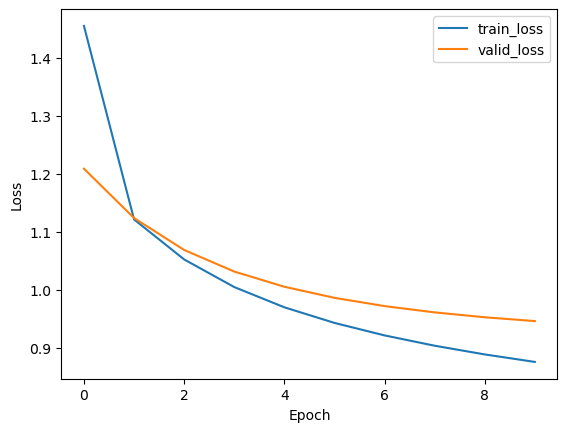

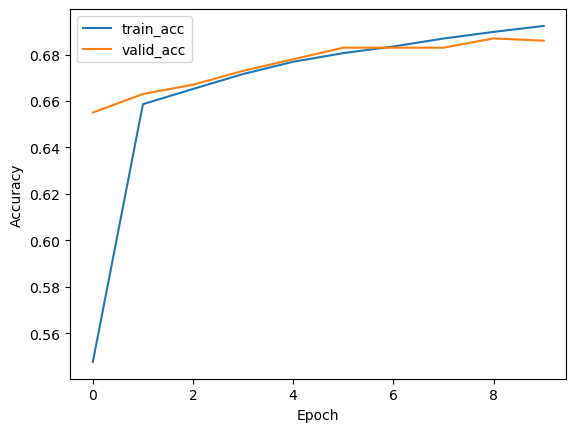

In [187]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## 1D Convolutional Neural Networks

In [4]:
from aeon.datasets import load_classification

### Dataset 

**Heartbeat**

This dataset is derived from the PhysioNet/CinC Challenge 2016. Heart sound recordings were sourced from several contributors around the world, collected at either a clinical or nonclinical environment, from both healthy subjects and pathological patients. The heart sound recordings were collected from different locations on the body. The typical four locations are aortic area, pulmonic area, tricuspid area and mitral area, but could be one of nine different locations. The sounds were divided into two classes: normal and abnormal. The normal recordings were from healthy subjects and the abnormal ones were from patients with a confirmed cardiac diagnosis. The patients suffer from a variety of illnesses, but typically they are heart valve defects and coronary artery disease patients. Heart valve defects include mitral valve prolapse, mitral regurgitation, aortic stenosis and valvular surgery. All the recordings from the patients were generally labeled as abnormal. Both healthy subjects and pathological patients include both children and adults. Each recording was truncated to 5 seconds. A Spectrogram of each instance was then created with a window size of 0.061 seconds and an overlap of 70%. Each instance in this multivariate dataset is arranged such that each dimension is a frequency band from the spectrogram. The two classes normal and abnormal consist of 113 and 296 respectivley. 

In [18]:
# Import the dataset
X_train, y_train = load_classification("Heartbeat", split="train")
X_test, y_test = load_classification("Heartbeat", split="test")
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((204, 61, 405), (204,), (205, 61, 405), (205,))

In [19]:
# Encode the labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
LABELS = le.classes_
le.classes_

array(['abnormal', 'normal'], dtype='<U8')

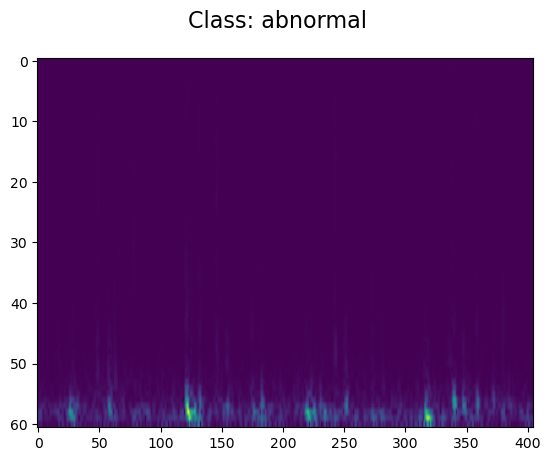

In [34]:
i = 100
plt.imshow(X_train[i], aspect='auto', cmap='viridis')
plt.suptitle('Class: {}'.format(LABELS[y_train[i]]), fontsize=16)
plt.show()

In [36]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_test, y_test)

0.7219512195121951

In [37]:
class Conv1DClassifier(nn.Module):
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=in_channels,
                out_channels=32,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool1d(output_size=1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        x shape: (batch_size, in_channels, sequence_length)
        """
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [88]:
net = NeuralNetClassifier(
    Conv1DClassifier,
    module__in_channels=X_train.shape[1],
    module__num_classes=len(le.classes_),

    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    max_epochs=300,
    batch_size=128,
    lr=1e-4,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
        Checkpoint(
            monitor="valid_acc_best", 
            load_best=True,
            f_history=None,
            f_optimizer=None,
        )
    ],
    device=DEVICE,

    train_split=ValidSplit(cv=0.2, stratified=True)
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.Conv1DClassifier'>,
  module__in_channels=61,
  module__num_classes=2,
)

In [89]:
net.fit(X_train, y_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss    cp     dur
-------  -----------  ------------  -----------  ------------  ----  ------
      1       0.3497        0.7176       0.2683        0.6971     +  0.0698
      2       0.5215        0.6985       0.2683        0.7001        0.0317
      3       0.5460        0.6841       0.2683        0.7029        0.0324
      4       0.6074        0.6725       0.2683        0.7050        0.0383
      5       0.6319        0.6629       0.3415        0.7066     +  0.0412
      6       0.6503        0.6546       0.4390        0.7079     +  0.0287
      7       0.6871        0.6474       0.4878        0.7090     +  0.0440
      8       0.7117        0.6410       0.5366        0.7099     +  0.0391
      9       0.7178        0.6351       0.5854        0.7107     +  0.0407
     10       0.7178        0.6294       0.6341        0.7115     +  0.0315
     11       0.7178        0.6239       0.6341        0.7122        0.0343
     12     

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Conv1DClassifier(
    (features): Sequential(
      (0): Conv1d(61, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
    )
    (pool): AdaptiveAvgPool1d(output_size=1)
    (classifier): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=128, out_features=2, bias=True)
    )
  ),
)

In [90]:
y_pred = net.predict(X_test)
accuracy_score(y_test, y_pred)

0.7609756097560976

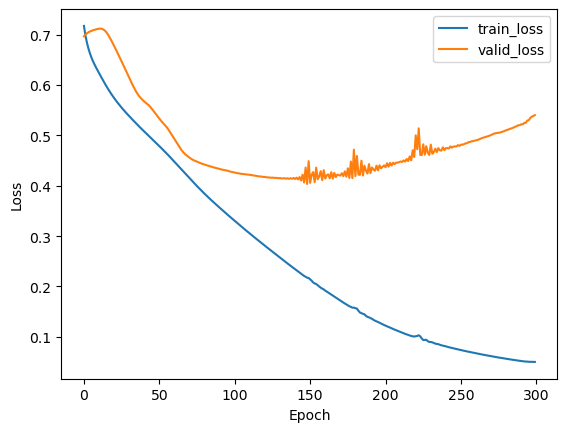

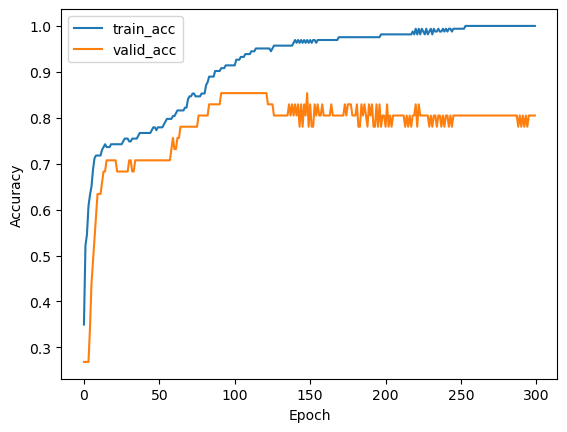

In [91]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

#### Rocket Variants

In [71]:
from aeon.classification.convolution_based import MiniRocketClassifier, MultiRocketHydraClassifier

In [72]:
clf = MiniRocketClassifier(n_jobs=-1)

In [73]:
clf.fit(X_train, y_train)

MiniRocketClassifier(n_jobs=-1)

In [74]:
clf.score(X_test, y_test)

0.7560975609756098

In [75]:
clf = MultiRocketHydraClassifier(n_jobs=-1)

In [76]:
clf.fit(X_train, y_train)

MultiRocketHydraClassifier(n_jobs=-1)

In [77]:
clf.score(X_test, y_test)

0.7414634146341463

## Exercises
- 1D-CNN: build a 1d cnn for the ECG200 dataset (see previous notebooks for how to import it)
- 2D-CNN: build a 2d cnn for the Pneumonia MNIST dataset (https://zenodo.org/records/10519652)